In [1]:
import os
import shutil
import subprocess
from pathlib import Path

CACHE_ROOT = Path.cwd() / ".cache"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_ROOT / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

texlive_root = Path("/opt/homebrew/Cellar/texlive")
tex_bin_candidates = [
    Path("/opt/homebrew/opt/texlive/bin"),
    *sorted(texlive_root.glob("*/bin"), reverse=True),
    Path("/opt/homebrew/bin"),
    Path("/Library/TeX/texbin"),
    Path("/usr/texbin"),
]
tex_lib_candidates = [
    Path("/opt/homebrew/opt/libpng/lib"),
    Path("/opt/homebrew/opt/texlive/lib"),
    *sorted(texlive_root.glob("*/lib"), reverse=True),
]

current_path = os.environ.get("PATH", "")
path_parts = current_path.split(":") if current_path else []
for texbin in tex_bin_candidates:
    if texbin.exists():
        texbin_str = str(texbin)
        if texbin_str not in path_parts:
            path_parts.insert(0, texbin_str)
os.environ["PATH"] = ":".join(path_parts)

current_dyld = os.environ.get("DYLD_LIBRARY_PATH", "")
dyld_parts = current_dyld.split(":") if current_dyld else []
for texlib in tex_lib_candidates:
    if texlib.exists():
        texlib_str = str(texlib)
        if texlib_str not in dyld_parts:
            dyld_parts.insert(0, texlib_str)
if dyld_parts:
    os.environ["DYLD_LIBRARY_PATH"] = ":".join(dyld_parts)

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import LogFormatterMathtext, LogLocator

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
except ImportError:
    set_matplotlib_formats = None

FORCE_TEX = True
CIFAR_CSV_PATH = "../../results/cifar100/cifar100_segmented.csv"
IMAGENET_CSV_PATH = "../../results/vggnet16/ALL_vggnet.csv"
TIME_COL = "all_time"
DEFAULT_TIMEOUT_S = 100.0
CSI_TAG_VALUE = "fix_nonmask"
BASELINE_LABEL = r"$\alpha\beta$-CROWN"
CSI_LABEL = r"$\alpha\beta$-CROWN w/ CSI [object]"
LINE_COLOR = "#090A0B"
RESULT_COLS = ["result", "status", "verified_status", "final_result", "verification_result"]
MODE_SETTINGS = {
    "safe": {
        "count_label": "safe certificates",
        "x_label": "Number of Safe Certificates",
    },
    "decided": {
        "count_label": "decided results (safe + unsafe)",
        "x_label": "Number of Decided Results",
    },
}

def normalize_tag(value):
    value = str(value).strip().lower()
    return value.replace("fixnonmask", "fix_nonmask").replace("fixmask", "fix_mask")

def latex_ready():
    has_renderer = shutil.which("dvipng") is not None or shutil.which("dvisvgm") is not None
    return shutil.which("latex") is not None and has_renderer

def has_tex_package(package_name):
    if shutil.which("kpsewhich") is None:
        return False
    return subprocess.run(
        ["kpsewhich", f"{package_name}.sty"],
        capture_output=True,
        text=True,
        check=False,
    ).returncode == 0

def configure_plot_style(force_tex=FORCE_TEX):
    use_tex = force_tex and latex_ready()
    preamble = r"\usepackage{fontawesome5}" if use_tex and has_tex_package("fontawesome5") else ""

    if set_matplotlib_formats is not None:
        if use_tex and shutil.which("dvisvgm") is not None:
            set_matplotlib_formats("svg")
        else:
            set_matplotlib_formats("png")

    if force_tex and not use_tex:
        print("LaTeX was requested but no compatible renderer was found. Falling back to Matplotlib serif text.")

    mpl.rcParams.update({
        "text.usetex": use_tex,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "text.latex.preamble": preamble,
        "font.size": 16,
        "axes.labelsize": 22,
        "axes.titlesize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 16,
        "axes.linewidth": 1.2,
        "grid.linewidth": 0.9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    return use_tex

def canonical_outcome(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.lower()
    out = pd.Series("unknown", index=series.index, dtype="object")
    out = out.mask(s.str.startswith("unsat") | s.str.contains(r"\bsafe\b", regex=True), "safe")
    out = out.mask(s.str.startswith("sat") | s.str.contains(r"\bunsafe\b", regex=True), "unsafe")
    out = out.mask(s.str.contains("timeout") | s.str.contains("unknown"), "unknown")
    return out

def outcome_mask(df: pd.DataFrame, mode: str) -> pd.Series:
    if mode not in MODE_SETTINGS:
        raise ValueError(f"Unsupported mode: {mode}")

    for col in RESULT_COLS:
        if col in df.columns:
            outcomes = canonical_outcome(df[col])
            if mode == "safe":
                return outcomes == "safe"
            return outcomes != "unknown"

    return pd.Series(mode == "decided", index=df.index, dtype=bool)

def cactus_xy(times: np.ndarray, timeout_s: float):
    times = np.clip(times.astype(float), 1e-3, timeout_s)
    times = np.sort(times)
    x = np.arange(1, len(times) + 1)
    return x, times

def resolve_timeout_s(df: pd.DataFrame, fallback=DEFAULT_TIMEOUT_S):
    if "timeout" not in df.columns:
        return float(fallback)

    timeout_values = pd.to_numeric(df["timeout"], errors="coerce").dropna()
    if timeout_values.empty:
        return float(fallback)

    return float(timeout_values.max())

def load_times(csv_path, mode="safe", k_value=None, csi_tag_value=CSI_TAG_VALUE):
    df = pd.read_csv(csv_path).copy()
    df["tag_norm"] = df["tag"].apply(normalize_tag)

    if "is_global" in df.columns:
        df["is_global"] = pd.to_numeric(df["is_global"], errors="coerce").fillna(0)
    else:
        df["is_global"] = 0

    if k_value is not None and "k" in df.columns:
        df["k_numeric"] = pd.to_numeric(df["k"], errors="coerce")
        df = df[df["k_numeric"] == float(k_value)].copy()

    timeout_s = resolve_timeout_s(df)
    df["selected"] = outcome_mask(df, mode)

    df_global = df[((df["tag_norm"] == "global") | (df["is_global"] == 1)) & df["selected"]].copy()
    df_object = df[(df["tag_norm"] == csi_tag_value) & df["selected"]].copy()

    global_times = pd.to_numeric(df_global[TIME_COL], errors="coerce").dropna().to_numpy()
    object_times = pd.to_numeric(df_object[TIME_COL], errors="coerce").dropna().to_numpy()
    return global_times, object_times, timeout_s

def plot_performance(csv_path, output_path, dataset_label, mode="safe", k_value=None, timeout_s=None, figsize=(8.2, 4.8)):
    if mode not in MODE_SETTINGS:
        raise ValueError(f"Unsupported mode: {mode}")

    configure_plot_style()
    global_times, object_times, inferred_timeout_s = load_times(csv_path, mode=mode, k_value=k_value)
    if timeout_s is None:
        timeout_s = inferred_timeout_s

    mode_settings = MODE_SETTINGS[mode]
    x_global, y_global = cactus_xy(global_times, timeout_s)
    x_object, y_object = cactus_xy(object_times, timeout_s)
    max_count = max(len(y_global), len(y_object), 2)

    print(dataset_label)
    print(f"{BASELINE_LABEL} {mode_settings['count_label']}: {len(y_global)}")
    print(f"{CSI_LABEL} {mode_settings['count_label']}: {len(y_object)}")
    print(f"Difference (CSI - baseline): {len(y_object) - len(y_global):+d}")

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(
        x_global,
        y_global,
        color=LINE_COLOR,
        linestyle="--",
        linewidth=3.0,
        label=f"{BASELINE_LABEL} ({len(y_global)})",
    )
    ax.plot(
        x_object,
        y_object,
        color=LINE_COLOR,
        linestyle="-",
        linewidth=3.0,
        label=f"{CSI_LABEL} ({len(y_object)})",
    )

    ax.axhline(timeout_s, color="#999999", linewidth=1.0, linestyle="--", alpha=0.8)
    ax.text(
        0.99,
        timeout_s,
        f" timeout = {int(timeout_s)} s ",
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="bottom",
    )

    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.set_xlabel(mode_settings["x_label"])
    ax.set_ylabel("Verification Time (s)")
    ax.set_xlim(1, max_count)
    ax.grid(axis="y", linestyle="--", alpha=0.30)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="lower right", frameon=False)

    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()

CIFAR-100 (k=1024, safe only)
$\alpha\beta$-CROWN safe certificates: 103
$\alpha\beta$-CROWN w/ CSI [object] safe certificates: 151
Difference (CSI - baseline): +48
Saved: cifar100_cactus_global_vs_object_safe.pdf


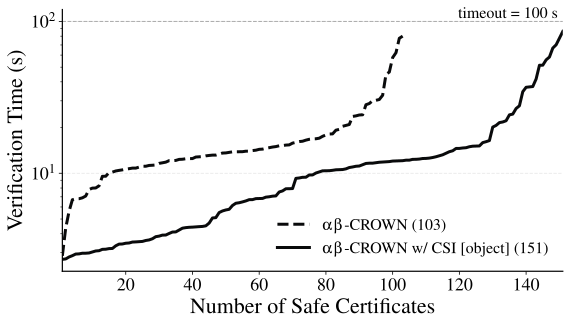

: 

In [ ]:
plot_performance(
    csv_path=CIFAR_CSV_PATH,
    output_path="cifar100_cactus_global_vs_object_safe.pdf",
    dataset_label="CIFAR-100 (k=1024, safe only)",
    mode="safe",
    k_value=1024,
)

CIFAR-100 (k=1024, safe + unsafe)
$\alpha\beta$-CROWN decided results (safe + unsafe): 128
$\alpha\beta$-CROWN w/ CSI [object] decided results (safe + unsafe): 169
Difference (CSI - baseline): +41
Saved: cifar100_cactus_global_vs_object_decided.pdf


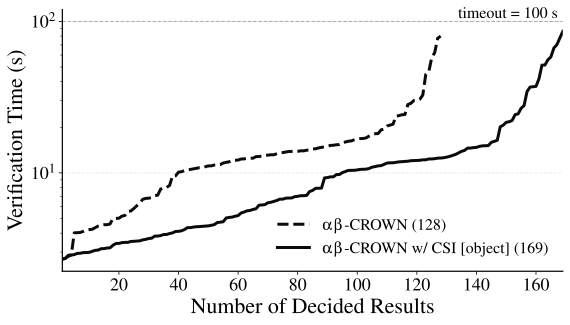

: 

In [ ]:
plot_performance(
    csv_path=CIFAR_CSV_PATH,
    output_path="cifar100_cactus_global_vs_object_decided.pdf",
    dataset_label="CIFAR-100 (k=1024, safe + unsafe)",
    mode="decided",
    k_value=1024,
)

ImageNet (k=50176, safe only)
$\alpha\beta$-CROWN safe certificates: 13
$\alpha\beta$-CROWN w/ CSI [object] safe certificates: 41
Difference (CSI - baseline): +28
Saved: imagenet_cactus_global_vs_object_k50176_safe.pdf


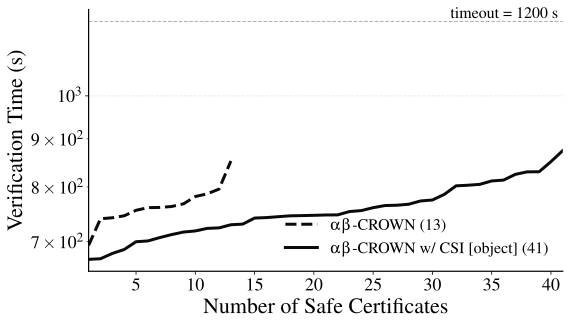

: 

In [ ]:
plot_performance(
    csv_path=IMAGENET_CSV_PATH,
    output_path="imagenet_cactus_global_vs_object_k50176_safe.pdf",
    dataset_label="ImageNet (k=50176, safe only)",
    mode="safe",
    k_value=50176,
)

ImageNet (k=50176, safe + unsafe)
$\alpha\beta$-CROWN decided results (safe + unsafe): 109
$\alpha\beta$-CROWN w/ CSI [object] decided results (safe + unsafe): 136
Difference (CSI - baseline): +27
Saved: imagenet_cactus_global_vs_object_k50176_decided.pdf


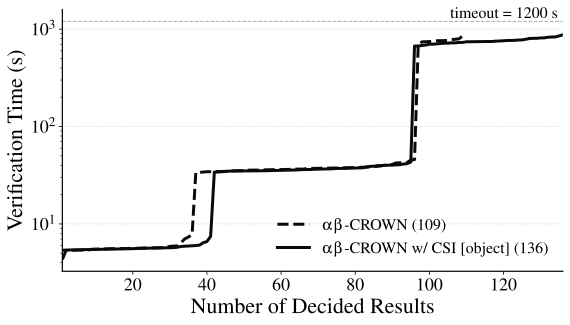

: 

In [ ]:
plot_performance(
    csv_path=IMAGENET_CSV_PATH,
    output_path="imagenet_cactus_global_vs_object_k50176_decided.pdf",
    dataset_label="ImageNet (k=50176, safe + unsafe)",
    mode="decided",
    k_value=50176,
)